# Análise Combinada da Produção Científica Anual - Scopus e WoS

Este notebook gera um gráfico combinando a produção científica anual das bases de dados Scopus e Web of Science.

In [1]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurar estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Caminhos dos arquivos Excel
scopus_excel_path = '../SCOPUS/analise_vs2/bibliometrix_scopus_vs2.xlsx'
wos_excel_path = '../WoS/analise_vs1/bibliometrix_wos.xlsx'

# Criar diretório para salvar gráficos
output_dir = 'graficos_combinados'
os.makedirs(output_dir, exist_ok=True)
print(f"Diretório criado: {output_dir}")

Diretório criado: graficos_combinados


In [2]:
# Ler arquivos Excel
xl_scopus = pd.ExcelFile(scopus_excel_path)
xl_wos = pd.ExcelFile(wos_excel_path)

print(f"Arquivo Excel da Scopus carregado: {scopus_excel_path}")
print(f"Total de abas na Scopus: {len(xl_scopus.sheet_names)}")
print(f"\nArquivo Excel da WoS carregado: {wos_excel_path}")
print(f"Total de abas na WoS: {len(xl_wos.sheet_names)}")

Arquivo Excel da Scopus carregado: ../SCOPUS/analise_vs2/bibliometrix_scopus_vs2.xlsx
Total de abas na Scopus: 79

Arquivo Excel da WoS carregado: ../WoS/analise_vs1/bibliometrix_wos.xlsx
Total de abas na WoS: 37


In [3]:
# Verificar se a aba AnnualSciProd existe em ambos os arquivos
print("Verificando abas disponíveis:")
print(f"Scopus - AnnualSciProd existe: {'AnnualSciProd' in xl_scopus.sheet_names}")
print(f"WoS - AnnualSciProd existe: {'AnnualSciProd' in xl_wos.sheet_names}")

Verificando abas disponíveis:
Scopus - AnnualSciProd existe: True
WoS - AnnualSciProd existe: True


In [4]:
# Ler dados de produção científica anual
df_scopus = pd.read_excel(xl_scopus, sheet_name='AnnualSciProd')
df_wos = pd.read_excel(xl_wos, sheet_name='AnnualSciProd')

print("Dados da Scopus:")
print(df_scopus.head())
print("\nDados da WoS:")
print(df_wos.head())

Dados da Scopus:
   Year  Articles
0  2016       138
1  2017       128
2  2018       151
3  2019       194
4  2020       180

Dados da WoS:
   Year  Articles
0  2016        66
1  2017        63
2  2018        73
3  2019        94
4  2020        92


In [5]:
# Verificar nomes das colunas
print("Colunas da Scopus:", df_scopus.columns.tolist())
print("Colunas da WoS:", df_wos.columns.tolist())

Colunas da Scopus: ['Year', 'Articles']
Colunas da WoS: ['Year', 'Articles']


Gráfico salvo: graficos_combinados/fig1_prod_cient_anual_combinada.png


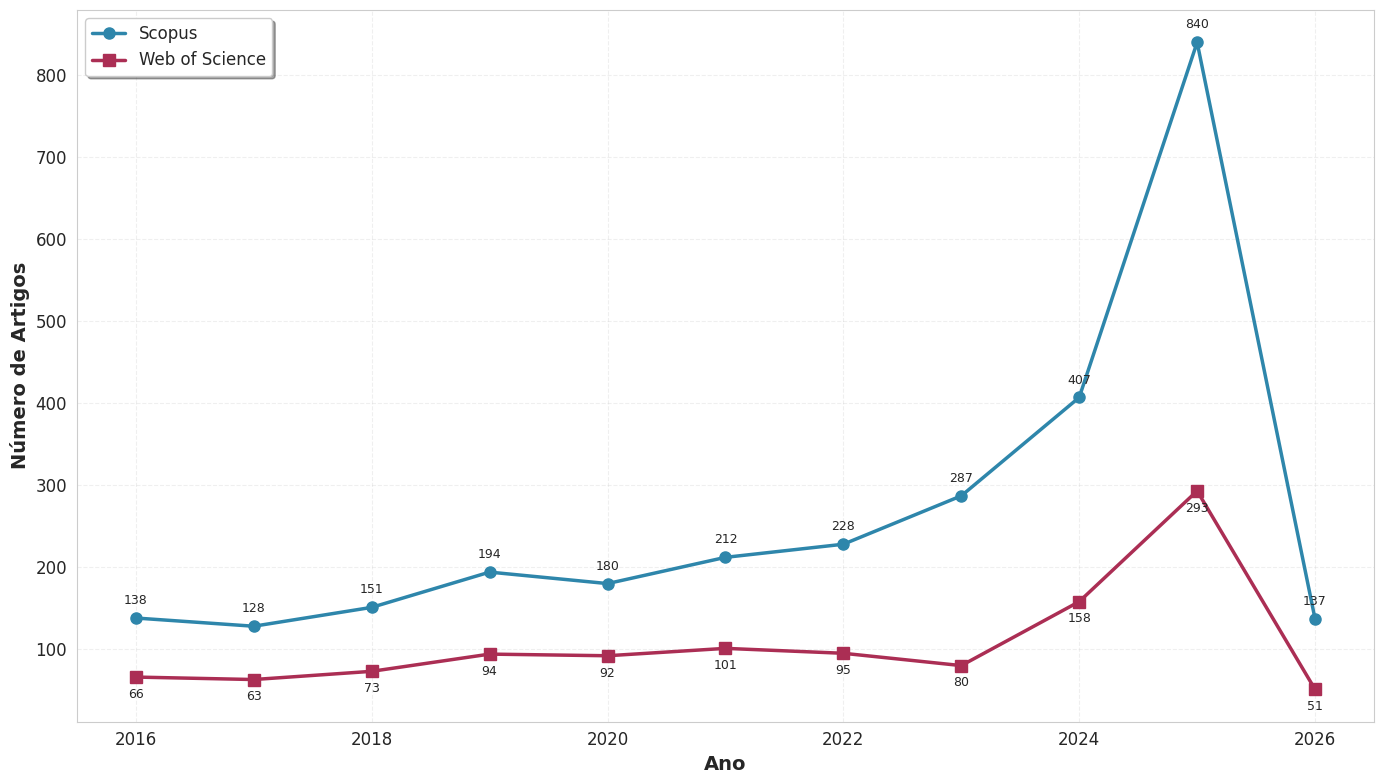

In [7]:
# Criar gráfico combinado de produção científica anual
plt.figure(figsize=(14, 8))

# Plot Scopus
plt.plot(df_scopus['Year'], df_scopus['Articles'], 
         marker='o', linewidth=2.5, color='#2E86AB', label='Scopus', markersize=8)

# Plot WoS
plt.plot(df_wos['Year'], df_wos['Articles'], 
         marker='s', linewidth=2.5, color='#AB2E54', label='Web of Science', markersize=8)

# Configurar título e labels
#plt.title('Produção Científica Anual - Scopus vs Web of Science', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=14, fontweight='bold')
plt.ylabel('Número de Artigos', fontsize=14, fontweight='bold')

# Adicionar legenda
plt.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)

# Adicionar grid
plt.grid(True, alpha=0.3, linestyle='--')

# Adicionar valores nos pontos
for i in range(len(df_scopus)):
    if df_scopus['Year'].iloc[i] in df_scopus['Year'].values:
        plt.annotate(str(df_scopus['Articles'].iloc[i]), 
                    (df_scopus['Year'].iloc[i], df_scopus['Articles'].iloc[i]),
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

for i in range(len(df_wos)):
    if df_wos['Year'].iloc[i] in df_wos['Year'].values:
        plt.annotate(str(df_wos['Articles'].iloc[i]), 
                    (df_wos['Year'].iloc[i], df_wos['Articles'].iloc[i]),
                    textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

# Ajustar layout
plt.tight_layout()

# Salvar gráfico
output_path = os.path.join(output_dir, 'fig1_prod_cient_anual_combinada.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"Gráfico salvo: {output_path}")

# Mostrar gráfico
plt.show()

In [9]:
df_scopus_med_cit = pd.read_excel(xl_scopus, sheet_name='AnnualCitPerYear')
df_wos_med_cit = pd.read_excel(xl_wos, sheet_name='AnnualCitPerYear')

Gráfico salvo: graficos_combinados/fig2_med_cit_anual_combinada.png


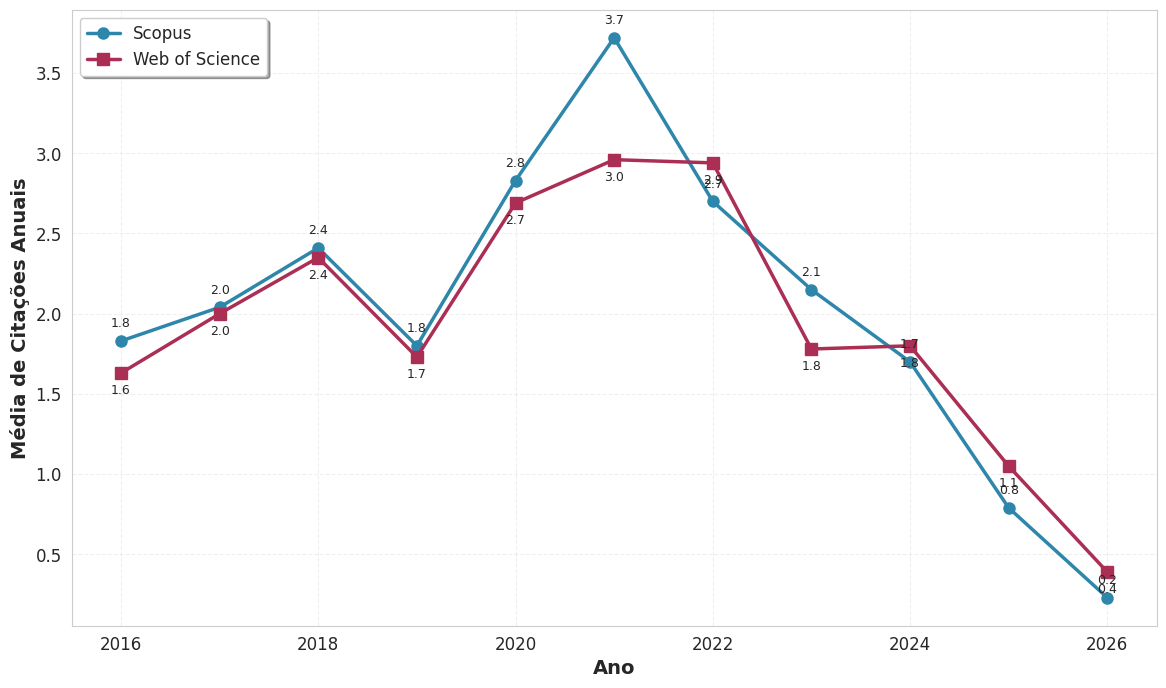

In [11]:
# Criar gráfico combinado da média de citações por ano
plt.figure(figsize=(14, 8))

# Plot Scopus
plt.plot(df_scopus_med_cit['Year'], df_scopus_med_cit['MeanTCperYear'], 
         marker='o', linewidth=2.5, color='#2E86AB', label='Scopus', markersize=8)

# Plot WoS
plt.plot(df_wos_med_cit['Year'], df_wos_med_cit['MeanTCperYear'], 
         marker='s', linewidth=2.5, color='#AB2E54', label='Web of Science', markersize=8)

# Configurar título e labels
# plt.title('Média de Citações por Ano - Scopus vs Web of Science', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ano', fontsize=14, fontweight='bold')
plt.ylabel('Média de Citações Anuais', fontsize=14, fontweight='bold')

# Adicionar legenda
plt.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)

# Adicionar grid
plt.grid(True, alpha=0.3, linestyle='--')

# Adicionar valores nos pontos - Scopus
for i in range(len(df_scopus_med_cit)):
    ano = df_scopus_med_cit['Year'].iloc[i]
    valor = df_scopus_med_cit['MeanTCperYear'].iloc[i]
    
    # Formatando para 1 casa decimal (ex: 3.4) para não poluir o gráfico
    plt.annotate(f"{valor:.1f}", 
                 (ano, valor),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Adicionar valores nos pontos - WoS
for i in range(len(df_wos_med_cit)):
    ano = df_wos_med_cit['Year'].iloc[i]
    valor = df_wos_med_cit['MeanTCperYear'].iloc[i]
    
    # xytext=(0,-15) coloca a anotação levemente abaixo do ponto para evitar sobreposição
    plt.annotate(f"{valor:.1f}", 
                 (ano, valor),
                 textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

output_path = os.path.join(output_dir, 'fig2_med_cit_anual_combinada.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"Gráfico salvo: {output_path}")
plt.show()

In [ ]:
import pandas as pd

# Ler arquivo Excel - verificar nomes das sheets
scopus_xl = pd.ExcelFile('Resultados_biblioshiny/SCOPUS/analise_vs2/bibliometrix_scopus_vs2.xlsx')
print(scopus_xl.sheet_names)

# Ler sheet de fontes
scopus_df = pd.read_excel('bibliometrix_scopus_vs2.xlsx', sheet_name='Sources')
wos_df = pd.read_excel('bibliometrix_wos.xlsx', sheet_name='Sources')
